# TEM-1 sequence-function landscape

This notebook builds a fitness landscape from the raw deep mutational
scanning counts of TEM-1 beta-lactamase (Firnberg, Labonte, Gray, and
Ostermeier, 2014, *Molecular Biology and Evolution*), available on MaveDB
as `urn:mavedb:00000070-a-3`: sequencing counts for 18,081 codon-level
variants across 13 ampicillin selection concentrations.

Beyond reproducing the original publication's main results, this notebook
adds a codon-level analysis of whether the specific codon used for a
substitution affects its measured fitness, and whether this depends on a
position's tolerance to substitution or its location at the start of the
gene.

## Key results

- The four known catalytic residues (Ser70, Lys73, Ser130, Glu166) are
  independently recovered as among the least tolerant positions in the
  protein, identified blind from the fitness data alone.
- Proline is the least tolerated substitution overall; methionine is the
  only substitution more favourable than the wild-type amino acid on
  average.
- Leu21, in the signal peptide, has the highest median fitness of any
  position, but shows a sharply divided substitution pattern: charged
  residues are strongly deleterious, most others are beneficial.
- Intolerant positions cluster along the sequence far more than expected
  by chance (permutation test, p < 0.001); beneficial positions do not.
- The choice of synonymous codon measurably affects fitness, especially
  in the first 16 positions of the gene, where the effect is about
  1.7-fold rather than 1.4-fold elsewhere. This is weakly consistent with
  a change in predicted mRNA structure at the start of the gene.
- Fitness scores and per-position tolerance computed with the simplified
  method used here are strongly correlated with the original
  publication's own published values (Spearman rho = 0.965 and 0.932),
  despite the methodological simplifications documented throughout this
  notebook.

Details, statistical tests, and their limitations are in the
corresponding steps below.

In [1]:
import copy
import itertools
import json
import re
import urllib.request

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import RNA
import scikit_posthocs as sp
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import kruskal, shapiro, spearmanr, wilcoxon


# --- Analysis parameters ---

# Minimum sequencing count for a variant to be included in the analysis.
# Justified in step 4 by inspecting the relationship between count and
# score variance on synonymous variants.
QC_MIN_COUNT = 5

# Position of the stop codon in the linear numbering of this gene.
# Variants at this position are excluded from the protein-level analysis.
STOP_CODON_POSITION = 287

# Position of the start codon in the linear numbering of this gene.
# Variants at this position act on translation initiation rather than on
# the amino acid, so they are excluded from the protein-level analysis.
START_CODON_POSITION = 1

# Number of positions per group in steps 7 and 8: the least tolerant,
# the most tolerant, and positions 2 to N + 1 of the gene (position 1 is
# the start codon). A pragmatic choice, see the justification at the
# start of step 7.
N_POSITIONS_PER_GROUP = 15

# Window size, in nucleotides, used to fold the mRNA structure around the
# start of the gene in step 9. Anchored at the start codon rather than
# centred on each mutation, so that it covers positions 2 to 16 regardless
# of where within them a substitution falls. Chosen after checking that
# the result is stable between 30 and 60 nucleotides.
WINDOW = 50

# --- Visualisation ---

# Amino acids ordered by chemical group, used to order heatmap columns
# and the fitness-per-amino-acid bar chart in step 7.
AA_ORDER = [
    "Ala", "Val", "Ile", "Leu", "Met",
    "Phe", "Trp", "Tyr",
    "Ser", "Thr", "Cys",
    "Asn", "Gln",
    "Asp", "Glu",
    "Lys", "Arg", "His",
    "Gly", "Pro",
]

# Colors for each chemical group, used together with AA_GROUPS
# in the fitness-per-amino-acid bar chart in step 7.
AA_COLORS = {
    "aliphatic hydrophobic": "mediumblue",
    "aromatic hydrophobic": "powderblue",
    "polar": "forestgreen",
    "negatively charged": "crimson",
    "positively charged": "lightpink",
    "structural": "gold",
}

# Chemical group membership for each amino acid, used with AA_COLORS.
AA_GROUPS = {
    "Ala": "aliphatic hydrophobic",
    "Val": "aliphatic hydrophobic",
    "Ile": "aliphatic hydrophobic",
    "Leu": "aliphatic hydrophobic",
    "Met": "aliphatic hydrophobic",
    "Phe": "aromatic hydrophobic",
    "Trp": "aromatic hydrophobic",
    "Tyr": "aromatic hydrophobic",
    "Ser": "polar",
    "Thr": "polar",
    "Cys": "polar",
    "Asn": "polar",
    "Gln": "polar",
    "Asp": "negatively charged",
    "Glu": "negatively charged",
    "Lys": "positively charged",
    "Arg": "positively charged",
    "His": "positively charged",
    "Gly": "structural",
    "Pro": "structural",
}

# One-letter to three-letter amino acid code, used to convert Data S2
# (Firnberg et al., 2014) into the three-letter format used elsewhere
# in this notebook.
THREE_LETTER_CODE = {
    "A": "Ala", "R": "Arg", "N": "Asn", "D": "Asp", "C": "Cys",
    "Q": "Gln", "E": "Glu", "G": "Gly", "H": "His", "I": "Ile",
    "L": "Leu", "K": "Lys", "M": "Met", "F": "Phe", "P": "Pro",
    "S": "Ser", "T": "Thr", "W": "Trp", "Y": "Tyr", "V": "Val",
}


# --- Biological data ---

# UniProt REST API endpoint for TEM-1 beta-lactamase (accession P62593).
# Used in step 7 to retrieve secondary structure annotations.
UNIPROT_URL = "https://rest.uniprot.org/uniprotkb/P62593.json"

# Wild-type TEM-1 coding sequence (UniProt P62593, 286 codons).
# Used in step 8 to reconstruct mutated codons from HGVS nucleotide
# notation.
TEM1_SEQUENCE = (
    "ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGGCATTTTGCCTTCCT"
    "GTTTTTGCTCACCCAGAAACGCTGGTGAAAGTAAAAGATGCTGAAGATCAGTTGGGTGCA"
    "CGAGTGGGTTACATCGAACTGGATCTCAACAGCGGTAAGATCCTTGAGAGTTTTCGCCCC"
    "GAAGAACGTTTTCCAATGATGAGCACTTTTAAAGTTCTGCTATGTGGCGCGGTATTATCC"
    "CGTGTTGACGCCGGGCAAGAGCAACTCGGTCGCCGCATACACTATTCTCAGAATGACTTG"
    "GTTGAGTACTCACCAGTCACAGAAAAGCATCTTACGGATGGCATGACAGTAAGAGAATTA"
    "TGCAGTGCTGCCATAACCATGAGTGATAACACTGCGGCCAACTTACTTCTGACAACGATC"
    "GGAGGACCGAAGGAGCTAACCGCTTTTTTGCACAACATGGGGGATCATGTAACTCGCCTT"
    "GATCGTTGGGAACCGGAGCTGAATGAAGCCATACCAAACGACGAGCGTGACACCACGATG"
    "CCTGCAGCAATGGCAACAACGTTGCGCAAACTATTAACTGGCGAACTACTTACTCTAGCT"
    "TCCCGGCAACAATTAATAGACTGGATGGAGGCGGATAAAGTTGCAGGACCACTTCTGCGC"
    "TCGGCCCTTCCGGCTGGCTGGTTTATTGCTGATAAATCTGGAGCCGGTGAGCGTGGGTCT"
    "CGCGGTATCATTGCAGCACTGGGGCCAGATGGTAAGCCCTCCCGTATCGTAGTTATCTAC"
    "ACGACGGGGAGTCAGGCAACTATGGATGAACGAAATAGACAGATCGCTGAGATAGGTGCC"
    "TCACTGATTAAGCATTGGTAA"
)


# --- HGVS parsing ---

# Regex patterns for parsing HGVS notation. The protein pattern matches
# strings such as "p.Ter287Tyr" or "p.Gly279Gly": a 3-letter wild-type
# amino acid, a 1-3 digit position, a 3-letter mutant amino acid.
HGVS_PRO_REGEX = re.compile(
    r"^p\.(?P<wt_aa>\w{3})(?P<position>\d{1,3})(?P<mut_aa>\w{3})$"
)

# The three nucleotide patterns cover all substitution types in the
# CCM-2 library: single-nucleotide substitution, deletion-insertion, and
# double substitution.
SUBSTITUTION_REGEX = re.compile(r"^c\.(\d+)([ATGC])>([ATGC])$")
DELINS_REGEX = re.compile(r"^c\.(\d+)_(\d+)delins([ATGC]+)$")
DOUBLE_SUBS_REGEX = re.compile(
    r"^c\.\[\d+[ATGC]>([ATGC]);\d+[ATGC]>([ATGC])\]$"
)


# --- Codon usage ---

# Codon usage table for E. coli highly expressed proteins.
# Derived from 15 highly expressed genes (groEL, tufA, rpsA, rpoA,
# rpoB, and others). Source: Lorimer et al., 2009, BMC Biotechnology
# 9:36, Table 3. Codon (RNA) mapped to (one-letter amino acid, fraction).
ECOLI_CODON_TABLE = {
    "UUU": ("F", 0.21), "UUC": ("F", 0.79),
    "UUA": ("L", 0.03), "UUG": ("L", 0.02),
    "UCU": ("S", 0.39), "UCC": ("S", 0.39),
    "UCA": ("S", 0.02), "UCG": ("S", 0.04),
    "UAU": ("Y", 0.20), "UAC": ("Y", 0.80),
    "UAA": ("*", 0.83), "UAG": ("*", 0.17),
    "UGU": ("C", 0.20), "UGC": ("C", 0.80),
    "UGA": ("*", 0.00), "UGG": ("W", 1.00),
    "CUU": ("L", 0.05), "CUC": ("L", 0.06),
    "CUA": ("L", 0.01), "CUG": ("L", 0.83),
    "CCU": ("P", 0.08), "CCC": ("P", 0.01),
    "CCA": ("P", 0.08), "CCG": ("P", 0.82),
    "CAU": ("H", 0.17), "CAC": ("H", 0.83),
    "CAA": ("Q", 0.14), "CAG": ("Q", 0.86),
    "CGU": ("R", 0.73), "CGC": ("R", 0.24),
    "CGA": ("R", 0.00), "CGG": ("R", 0.01),
    "AUU": ("I", 0.12), "AUC": ("I", 0.86),
    "AUA": ("I", 0.02), "AUG": ("M", 1.00),
    "ACU": ("T", 0.36), "ACC": ("T", 0.56),
    "ACA": ("T", 0.02), "ACG": ("T", 0.05),
    "AAU": ("N", 0.09), "AAC": ("N", 0.91),
    "AAA": ("K", 0.81), "AAG": ("K", 0.19),
    "AGU": ("S", 0.01), "AGC": ("S", 0.15),
    "AGA": ("R", 0.02), "AGG": ("R", 0.00),
    "GUU": ("V", 0.57), "GUC": ("V", 0.07),
    "GUA": ("V", 0.21), "GUG": ("V", 0.15),
    "GCU": ("A", 0.45), "GCC": ("A", 0.07),
    "GCA": ("A", 0.28), "GCG": ("A", 0.21),
    "GAU": ("D", 0.28), "GAC": ("D", 0.72),
    "GAA": ("E", 0.83), "GAG": ("E", 0.17),
    "GGU": ("G", 0.48), "GGC": ("G", 0.50),
    "GGA": ("G", 0.00), "GGG": ("G", 0.01),
}

In [2]:
def get_ambler_label(pos):
    """Return the Ambler label for a given linear position, e.g. 'Ser70'.

    Requires `protein_variants_qc` to be defined (step 4 onwards).

    Args:
        pos (int): linear position in the TEM-1 sequence (1-indexed).

    Returns:
        str: wild-type amino acid and Ambler number, e.g. 'Ser70'.
    """
    row = protein_variants_qc[
        protein_variants_qc["position"] == pos
    ].iloc[0]
    return row["wt_aa"] + str(row["ambler"])


def get_wt_codon(position):
    """Return the wild-type codon at the given amino acid position.

    Called internally by get_mutated_codon; not used directly in the
    notebook.

    Args:
        position (int): amino acid position in the TEM-1 sequence
            (1-indexed).

    Returns:
        str: three-nucleotide DNA codon, e.g. 'ATG'.
    """
    codon_start = (position - 1) * 3
    return TEM1_SEQUENCE[codon_start:codon_start + 3]


def get_mutated_codon(mutation, position):
    """Return the mutated codon for a given HGVS nucleotide notation.

    Handles three notation types present in the CCM-2 library:
    single-nucleotide substitution, deletion-insertion, and double
    substitution. Returns None if the notation does not match any
    known pattern.

    Args:
        mutation (str): HGVS nucleotide notation, e.g. 'c.208T>A'.
        position (int): amino acid position in the TEM-1 sequence
            (1-indexed).

    Returns:
        str: three-nucleotide DNA codon, or None if unrecognised.
    """
    codon = list(get_wt_codon(position))
    substitution_result = SUBSTITUTION_REGEX.search(mutation)
    delins_result = DELINS_REGEX.search(mutation)
    double_subs_result = DOUBLE_SUBS_REGEX.search(mutation)
    if substitution_result:
        nuc_index = int(substitution_result.group(1)) - 1
        codon[nuc_index % 3] = substitution_result.group(3)
        return "".join(codon)
    elif delins_result:
        new_nuc = delins_result.group(3)
        if len(new_nuc) == 3:
            return new_nuc
        nuc_index = int(delins_result.group(1)) - 1
        first_position = nuc_index % 3
        # offset between the two substituted nucleotides within the codon
        second_position = (
            first_position
            + int(delins_result.group(2))
            - int(delins_result.group(1))
        )
        codon[first_position] = new_nuc[0]
        codon[second_position] = new_nuc[1]
        return "".join(codon)
    elif double_subs_result:
        codon[0] = double_subs_result.group(1)
        codon[2] = double_subs_result.group(2)
        return "".join(codon)
    return None


def compute_spreads(subset, column, min_variants=2):
    """Return the fitness and column spreads per position/AA pair.

    For each (position, mut_aa) pair in subset with at least
    min_variants variants, identifies the variant with the highest w and
    the variant with the lowest w. The fitness spread is log2 of the
    ratio between the two, the column spread is the difference in the
    given column between the two.

    Args:
        subset (pd.DataFrame): filtered rows of protein_variants_qc,
            must contain columns 'position', 'mut_aa', 'w', and the
            column named by the column argument.
        column (str): name of the column to compare between the best
            and the worst codon, e.g. 'codon_freq' or 'delta_mfe'.
        min_variants (int): minimum number of variants a pair needs to
            be kept. A pair with a single variant has no spread.

    Returns:
        tuple: (log2_spread, col_spread), two numpy arrays of the same
            length, one per kept (position, mut_aa) pair.
    """
    groups = subset.groupby(["position", "mut_aa"])["w"]
    is_kept = groups.count() >= min_variants
    idx_best = groups.idxmax()[is_kept]
    idx_worst = groups.idxmin()[is_kept]
    cols = [column, "w"]
    best = subset.loc[idx_best, cols]
    worst = subset.loc[idx_worst, cols]
    log2_spread = np.log2(best["w"].values / worst["w"].values)
    col_spread = best[column].values - worst[column].values
    return log2_spread, col_spread


def p_to_stars(p_value):
    """Return the significance label drawn above a boxplot comparison.

    Args:
        p_value (float): p-value of a pairwise comparison.

    Returns:
        str: '***' if p < 0.001, '**' if p < 0.01, '*' if p < 0.05,
            'ns' otherwise.
    """
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

## Step 1: Load and validate the raw data

Before parsing any variant, we load the raw counts file and check that it
matches what we expect from its documentation: 18,081 rows (one per possible
codon substitution across the 287 codons of TEM-1), no duplicate variants,
no missing values, and a `c_total` column that is consistent with the sum
of the 13 ampicillin concentration columns.

In [3]:
variants = pd.read_csv("urn_mavedb_00000070-a-3_counts.csv")

print(f"Shape: {variants.shape[0]} rows, {variants.shape[1]} columns")
print()
print("Column types:")
print(variants.dtypes.value_counts())
print()
print("Missing values per column:")
print(variants.isna().sum())
print()

n_unique_accessions = variants["accession"].nunique()
print(f"Unique accessions: {n_unique_accessions} out of {len(variants)}")

concentration_columns = [
    col for col in variants.columns
    if col.startswith("c_") and col != "c_total"
]
print(f"Concentration columns found: {concentration_columns}")

# Ampicillin concentrations in µg/mL, in the same order as the columns.
concentrations = [
    float(col.removeprefix("c_")) for col in concentration_columns
]

computed_total = variants[concentration_columns].sum(axis=1)
mismatches = variants[computed_total != variants["c_total"]]
print(f"Rows where c_total does not match the computed sum: {len(mismatches)}")

Shape: 18081 rows, 18 columns

Column types:
int64    15
str       3
Name: count, dtype: int64

Missing values per column:
accession    0
hgvs_nt      0
hgvs_pro     0
c_0.25       0
c_0.5        0
c_1          0
c_2          0
c_4          0
c_8          0
c_16         0
c_32         0
c_64         0
c_128        0
c_256        0
c_512        0
c_1024       0
c_total      0
ambler       0
dtype: int64

Unique accessions: 18081 out of 18081
Concentration columns found: ['c_0.25', 'c_0.5', 'c_1', 'c_2', 'c_4', 'c_8', 'c_16', 'c_32', 'c_64', 'c_128', 'c_256', 'c_512', 'c_1024']
Rows where c_total does not match the computed sum: 0


### Result

The file contains 18,081 rows and 18 columns, matching the expected size
of the library (287 codon positions x 63 possible codon substitutions),
with no missing values and one unique `accession` per row. `c_total`
equals the sum of the 13 concentration columns for every row (0
mismatches out of 18,081): a basic sanity check that the file has been
read and understood correctly before building on it.

## Genotype coverage across the selection gradient

Before computing any fitness score, it is useful to see how many distinct
genotypes are represented at each ampicillin concentration, as a visual
check of the bandpass selection design described in the original
publication, ahead of the weighted average (equation 4) used to compute
fitness scores.

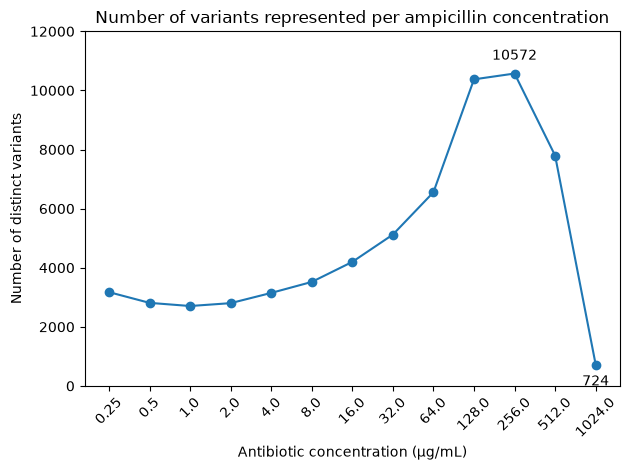

In [4]:
variants_per_conc = (variants[concentration_columns] != 0).sum(axis=0)

fig, ax = plt.subplots()
ax.plot(concentrations, variants_per_conc, marker="o")
ax.set_xlabel("Antibiotic concentration (µg/mL)")
ax.set_ylabel("Number of distinct variants")
ax.set_title("Number of variants represented per ampicillin concentration")
ax.set_xscale("log", base=2)
ax.set_ylim(0, 12000)

max_position = variants_per_conc.argmax()
min_position = variants_per_conc.argmin()

ax.annotate(
    f"{variants_per_conc.iloc[max_position]}",
    xy=(concentrations[max_position], variants_per_conc.iloc[max_position]),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
)
ax.annotate(
    f"{variants_per_conc.iloc[min_position]}",
    xy=(concentrations[min_position], variants_per_conc.iloc[min_position]),
    xytext=(0, -15),
    textcoords="offset points",
    ha="center",
)
ax.set_xticks(concentrations)
ax.set_xticklabels([str(c) for c in concentrations], rotation=45)
fig.tight_layout()

### Interpretation

The number of distinct variants rises from 2,704 at 1 µg/mL to a peak of
10,572 at 256 µg/mL, then collapses to 724 at 1024 µg/mL. This matches the
bandpass design of the selection: each plate selects for beta-lactamase
activity within a specific window for that concentration, not simply for
"resistant enough", so fewer variants qualify as the concentration rises,
producing a sharp drop rather than a gradual one. The slight dip between
0.25 and 1 µg/mL suggests the selection also excludes some of the least
functional variants even at low concentrations.

This distribution also justifies equation 4 itself: since a variant's
counts concentrate in a narrow window of concentrations rather than
spreading evenly across all 13, a fitness score using the full gradient,
weighted by counts, is more appropriate than any single input/output
concentration pair.

## Step 2: Parse the protein-level variant

The wild-type amino acid, position, and mutant amino acid are extracted
from `hgvs_pro`, and variants synonymous to the wild type (same amino
acid on both sides) are flagged. This flag is used both for the internal
quality control in a later step and to identify the stop codon variants
set aside below.

In [5]:
extracted = variants["hgvs_pro"].str.extract(HGVS_PRO_REGEX)
variants[extracted.columns] = extracted

n_unmatched = extracted.isna().any(axis=1).sum()
print(f"Rows where hgvs_pro did not match the expected pattern: {n_unmatched}")

variants["position"] = variants["position"].astype(int)
variants["is_wt_synonymous"] = variants["wt_aa"] == variants["mut_aa"]

n_synonymous = variants["is_wt_synonymous"].sum()
print(f"Synonymous-to-wild-type variants: {n_synonymous}")

Rows where hgvs_pro did not match the expected pattern: 0
Synonymous-to-wild-type variants: 761


### Cross-check against the published value

Firnberg et al. report 725 alleles synonymous to wild-type TEM-1. The raw
count above (761) does not match directly, since it does not yet apply
their two implicit conditions: a minimum allele count of 5, and exclusion
of the stop codon position, whose synonymous variants are a distinct
biological case (nonsense suppression) rather than a protein substitution.

In [6]:
reference_check = variants[
    (variants["c_total"] >= QC_MIN_COUNT)
    & (variants["position"] != STOP_CODON_POSITION)
    & (variants["is_wt_synonymous"])
]
print(
    f"Synonymous variants matching the paper's criteria: "
    f"{len(reference_check)}"
)

Synonymous variants matching the paper's criteria: 725


### Result

725 variants, an exact match with the published figure, confirming both
the `hgvs_pro` parsing and the interpretation of the count threshold.

Stop codon variants (position 287) are set aside from here on: without
the plasmid sequence downstream of the gene, a readthrough mutation
cannot be interpreted, so no biological conclusion could be drawn from
including them. This is a scope decision, distinct from the count-based
filter above.

Position 1, the start codon, is also set aside: its variants mostly act
on translation initiation rather than the amino acid, so their `w` does
not measure substitution tolerance. Methionine has a single codon, so
this position has no synonymous variants and the count of 725 is
unchanged.

In [7]:
excluded_positions = [START_CODON_POSITION, STOP_CODON_POSITION]
protein_variants = variants[
    ~variants["position"].isin(excluded_positions)
].copy()
print(
    f"Variants remaining after removing the start and stop codon "
    f"positions: {len(protein_variants)}"
)

Variants remaining after removing the start and stop codon positions: 17955


`protein_variants` is the working table until the count filter in step
4, when `protein_variants_qc` takes over as the reference for the rest
of the notebook. `variants` is kept untouched in case the full dataset is
needed again. The minimum allele count filter (`QC_MIN_COUNT`) is
revisited once fitness scores are available, following an approach
similar to supplementary figure S3 of the original publication.

## Step 3: Compute the normalized fitness score

For each variant, an unnormalized fitness score is computed following
equation 4 of the original publication: a weighted average of
log2(ampicillin concentration), weighted by the sequencing counts
observed at each concentration.

f_i = [ sum_p( c_i,p * log2(a_p) ) ] / [ sum_p( c_i,p ) ]

where `c_i,p` is the count of variant `i` at concentration `p`, and `a_p`
is that concentration in µg/mL; the denominator is the `c_total` column
from step 1. Log2 is used because the growth response to ampicillin dose
is approximately symmetric on this scale, and because the 13
concentrations double at each step, making log2 concentration evenly
spaced.

This is a simplified version of equation 4: the original publication
restricts the sum, per allele, to the 4 adjacent plates with the highest
combined counts, rather than all 13. Using all 13 concentrations is
simpler but more sensitive to noise at low counts, as shown in step 4.

In [8]:
log2_concentrations = np.log2(
    pd.Series(concentrations, index=concentration_columns)
)
protein_variants["n_plates_present"] = (
    protein_variants[concentration_columns] > 0
).sum(axis=1)

protein_variants["f"] = (
    (protein_variants[concentration_columns] * log2_concentrations).sum(axis=1)
    / protein_variants["c_total"]
)

### Wild-type reference score

`f_WT` is computed by pooling the raw counts of every synonymous-to-wild-
type allele (already excluding the stop codon, since `protein_variants`
does not include it), then applying the same formula to this pooled row.

No minimum count filter is applied to this pooling step, unlike
individual variants in step 4: since counts are summed before the formula
is applied, an allele with few reads barely affects the pooled sum, so it
cannot meaningfully bias `f_WT` even though its own score would be
unreliable alone.

In [9]:
wt_pooled_counts = protein_variants.loc[
    protein_variants["is_wt_synonymous"], concentration_columns
].sum()
f_WT = (
    (wt_pooled_counts * log2_concentrations).sum()
    / wt_pooled_counts.sum()
)

# equation 5 of Firnberg et al. (2014): w = 2^(f - f_WT)
protein_variants["w"] = np.exp2(protein_variants["f"] - f_WT)

synonymous_variants = protein_variants[
    protein_variants["is_wt_synonymous"]
].copy()

### Validation against published fitness values

Before continuing, `w` is checked against the fitness values published
in Firnberg et al.'s Data S2 (amino-acid level). Since several codons can
encode the same amino acid, the median `w` across codons for a given
position and substituted amino acid is used for this comparison.

In [10]:
published = pd.read_excel(
    "Data_S1-S4.xlsx", sheet_name="S2 Missense mutation fitnesses"
)
article_w = published[["Ambler Position", "Mutant AA", "Fitness"]]
article_w = article_w.dropna(subset="Fitness")
article_w["mut_aa"] = article_w["Mutant AA"].map(THREE_LETTER_CODE)
article_w = article_w.rename(
    columns={"Ambler Position": "ambler", "Fitness": "article_fitness"}
)
article_w = article_w.drop(columns="Mutant AA")
article_w["ambler"] = article_w["ambler"].astype(int)

our_w = (
    protein_variants.groupby(["ambler", "mut_aa"])["w"].median().reset_index()
)
our_w = our_w.rename(columns={"w": "our_fitness"})

merged_w = our_w.merge(article_w, on=["ambler", "mut_aa"], how="inner")
statistic, _ = spearmanr(merged_w["our_fitness"], merged_w["article_fitness"])

print(f"Amino acid substitutions matched: {len(merged_w)}")
print(f"Spearman correlation with published fitness: rho = {statistic:.3f}")

Amino acid substitutions matched: 5450
Spearman correlation with published fitness: rho = 0.965


C:\Users\MélineKURIC\AppData\Roaming\Python\Python314\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


The two sets of fitness values are strongly correlated (Spearman,
rho = 0.965, p < 0.001, n = 5450), despite the simplified equation used
here. This confirms the simplification does not distort the overall
fitness landscape and gives confidence in the analyses that follow.

## Step 4: Choose a minimum count threshold

Synonymous-to-wild-type variants are expected to have `w` close to 1 on
average, though not for every allele: codon choice itself can have a
real, biologically driven effect on fitness (documented in the original
publication for the start of the gene, and addressed here in step 8). The
*magnitude* of a real codon effect is not expected to depend on
sequencing count, since it is a property of the sequence rather than of
how often it was read. A narrowing of the spread of `w` with increasing
count is therefore best explained by decreasing measurement noise, even
if some genuine codon-level variation remains mixed in.

This check cannot be done directly on the full dataset: non-synonymous
variants are not all expected to share the same true fitness, so any
spread among them mixes real biological variation with noise. The average
fitness itself also decreases with count in the full dataset, since the
most deleterious variants grow poorly at every concentration and
accumulate fewer counts. An aggressive count filter would
disproportionately remove exactly the intolerant, functionally important
variants needed in step 7.

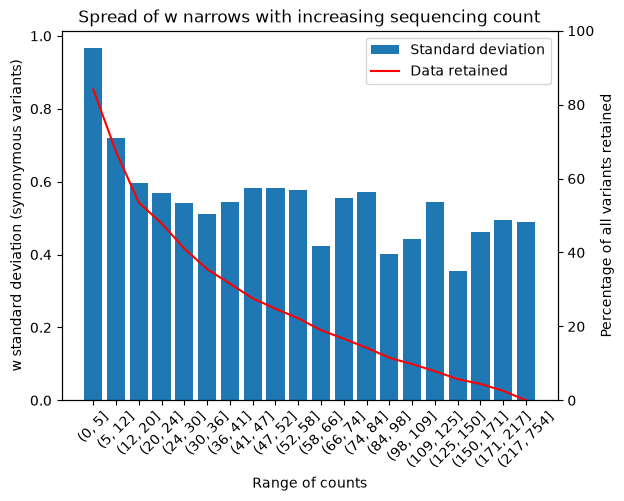

In [11]:
bins = [
    0, 5, 12, 20, 24, 30, 36, 41, 47, 52, 58, 66, 74, 84, 98, 109, 125,
    150, 171, 217, synonymous_variants["c_total"].max() + 1,
]
synonymous_variants["count_bin"] = pd.cut(
    synonymous_variants["c_total"], bins=bins
)
qc_summary = (
    synonymous_variants.groupby("count_bin", observed=False)["w"]
    .agg(["std", "count"])
)
bin_labels = qc_summary.index.astype(str)

percent_retained = [
    (protein_variants["c_total"] >= qc_min).mean() * 100
    for qc_min in bins[1:]
]

fig, ax1 = plt.subplots()
ax1.bar(bin_labels, qc_summary["std"], label="Standard deviation")
ax1.set_xlabel("Range of counts")
ax1.set_ylabel("w standard deviation (synonymous variants)")
ax1.set_title("Spread of w narrows with increasing sequencing count")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(bin_labels, percent_retained, color="red", label="Data retained")
ax2.set_ylabel("Percentage of all variants retained")
ax2.set_ylim(0, 100)

bars_legend, bars_labels = ax1.get_legend_handles_labels()
line_legend, line_labels = ax2.get_legend_handles_labels()
ax1.legend(bars_legend + line_legend, bars_labels + line_labels)

### Decision

The standard deviation drops sharply between the first two count ranges,
then flattens into a plateau after roughly 30 to 50 counts, with no clear
further improvement beyond that point. The bin edges used here were
chosen to give roughly balanced group sizes (27 to 44 variants per bin),
confirming that the sharp initial drop is not an artifact of having too
few variants in the lowest range.

`QC_MIN_COUNT = 5` is kept as the threshold for individual variant scores
from here on. A stricter threshold (e.g. 50) would remove about three
quarters of the dataset, disproportionately excluding the most
deleterious variants rather than a random sample of noisy ones. A
threshold of 5 leaves noticeable residual noise, but this is judged a
smaller cost than losing the ability to detect intolerant positions in
step 7.

This value happens to match the original publication's own threshold,
though the justification here is independent: it comes directly from
this dataset's noise-versus-count trade-off (above), while Firnberg et
al. pair their threshold with the 4-plate window of step 3, which already
reduces noise beforehand.

In [12]:
protein_variants_qc = protein_variants[
    protein_variants["c_total"] >= QC_MIN_COUNT
].copy()
print(f"Variants remaining after the count filter: {len(protein_variants_qc)}")

Variants remaining after the count filter: 15103


## Step 5: Internal controls

The synonymous-to-wild-type variants used in step 4 to calibrate the
count threshold are now used to check that the fitness score behaves as
biologically expected, rather than to assess measurement reliability. A
second check, on nonsense variants, completes this step: synonymous
variants should behave like the wild type, and nonsense variants, which
introduce a premature stop codon, should show a strongly reduced fitness.

Before the synonymous check, the number of plates on which a variant
appears is introduced as an additional quality indicator, used below to
select a well-behaved example.

### Plate spread: a further source of noise

A single, correctly measured mutation is expected to appear on only a
narrow window of adjacent concentration plates. To check this, variants
are grouped by the number of plates on which they appear, and the median
`w` is shown for each group.

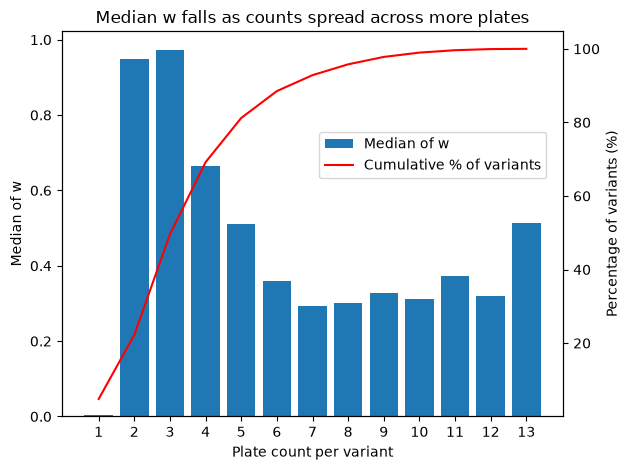

In [13]:
summary = protein_variants_qc.groupby("n_plates_present")["w"].median()

fig, ax1 = plt.subplots()
ax1.bar(summary.index.astype(str), summary, label="Median of w")
ax1.set_xlabel("Plate count per variant")
ax1.set_ylabel("Median of w")
ax1.set_title("Median w falls as counts spread across more plates")

percent_data = [
    (protein_variants_qc["n_plates_present"] <= plate_min).sum()
    / len(protein_variants_qc) * 100
    for plate_min in summary.index
]

ax2 = ax1.twinx()
ax2.plot(
    summary.index.astype(str), percent_data, color="red",
    label="Cumulative % of variants",
)
ax2.set_ylabel("Percentage of variants (%)")

bars_legend, bars_labels = ax1.get_legend_handles_labels()
line_legend, line_labels = ax2.get_legend_handles_labels()
ax1.legend(
    bars_legend + line_legend, bars_labels + line_labels,
    bbox_to_anchor=(0.5, 0.6),
)
fig.tight_layout()

Median `w` peaks at 2 to 3 plates (0.95 and 0.97), the narrow window a
correctly measured mutation is expected to occupy. It falls steadily from
there to a noisy plateau between roughly 0.3 and 0.5 beyond 6 to 7
plates. The original publication attributes such spread to sequencing
errors or an unintended second mutation elsewhere in the plasmid, rather
than to the intended substitution. A cutoff at 4 plates would retain
about 69% of `protein_variants_qc`.

This is not corrected here: none of the four known active-site positions
(S70, K73, S130, E166) exceed 8 plates, so the interpretation planned for
step 7 is unaffected, and this notebook does not implement the original
publication's 4-plate window (see step 3). Plate spread is kept as a
documented limitation of the simplified fitness calculation rather than a
second filtering threshold; 4 plates or fewer is treated below as a
normal profile.

### Synonymous-to-wild-type check

The naive expectation that synonymous-to-wild-type variants have `w`
close to 1 does not hold at face value on the full set of 725 synonymous
variants.

In [14]:
print(
    f"Median w across all synonymous variants: "
    f"{synonymous_variants['w'].median():.2f}"
)

is_well_measured = synonymous_variants["c_total"] >= 100
has_normal_spread = synonymous_variants["n_plates_present"] <= 4
candidates = synonymous_variants[is_well_measured & has_normal_spread]

distance_from_one = (candidates["w"] - 1).abs()
example = candidates.loc[distance_from_one.idxmax()]

print(
    f"Well-measured synonymous variant with a normal plate spread "
    f"({example['hgvs_nt']}, {example['c_total']:.0f} counts, "
    f"{example['n_plates_present']:.0f} plates): w = {example['w']:.3f}"
)

Median w across all synonymous variants: 1.38
Well-measured synonymous variant with a normal plate spread (c.663G>C, 130 counts, 3 plates): w = 2.262


As shown in step 4, most of this apparent deviation is explained by
sampling noise at low counts rather than by biology: the median of a
small sample drawn from a skewed distribution deviates from the true
population value purely by chance, even when every draw comes from the
same source.

This does not account for every case, however. The variant shown above
is well-measured with a normal plate spread, ruling out both sources of
noise discussed so far, yet still shows a `w` of about 2.26, a genuine
more-than-twofold fitness gain from a synonymous substitution. This is
consistent with the original publication's finding that synonymous codon
choice can have a real effect on fitness, likely through mRNA structure
or translation rate. The broader question is addressed in step 8.

### Nonsense check

Nonsense variants, which introduce a premature stop codon, are expected
to show a strongly reduced fitness, close to complete loss of function.

In [15]:
nonsense_variants = protein_variants_qc[protein_variants_qc["mut_aa"] == "Ter"]
synonymous_qc = protein_variants_qc[protein_variants_qc["is_wt_synonymous"]]

print(f"Median w, nonsense variants: {nonsense_variants['w'].median():.3f}")
print(f"Median w, synonymous variants: {synonymous_qc['w'].median():.3f}")

nonsense_reads = nonsense_variants[concentration_columns].sum()
low_concentration_share = (
    nonsense_reads[concentration_columns[:3]].sum()
    / nonsense_reads.sum() * 100
)
highest_concentration_share = (
    nonsense_reads["c_1024"] / nonsense_reads.sum() * 100
)
print(
    "Share of nonsense reads at the 3 lowest concentrations: "
    f"{low_concentration_share:.1f}%"
)
print(
    "Share of nonsense reads at the highest concentration: "
    f"{highest_concentration_share:.2f}%"
)

Median w, nonsense variants: 0.006
Median w, synonymous variants: 1.364
Share of nonsense reads at the 3 lowest concentrations: 38.2%
Share of nonsense reads at the highest concentration: 0.04%


The contrast with the synonymous check above is stark: a median `w` of
0.006 for nonsense variants against 1.36 for synonymous ones, confirming
that the fitness calculation clearly separates a functional variant from
a non-functional one.

Nonsense variants are not entirely absent from the data, however: 38% of
their reads come from the three lowest concentrations, against 0.04% at
the highest. Even an inactive variant is not eliminated at very low
ampicillin doses, below *E. coli*'s own baseline tolerance, and the
strain used carries a suppressor tRNA (`supE44`) that reads through a
UAG stop codon followed by a purine at a mean efficiency of 7 to 10%,
producing a small amount of full-length protein in some cells. Together,
these explain the counts at low to moderate concentrations and their
near disappearance at high ones.

## Step 6: Score distribution and position-level summary

Three views of the fitness scores are built here, from least to most
subdivided: the distribution of `w` across the dataset as a whole, a
single summary score per position, and a full heatmap of median `w` by
position and substituted amino acid.

### Score distribution

Synonymous, missense, and nonsense variants are shown separately, as in
figure 1 of the original publication, to check that the fitness
calculation places each category where expected.

Missense variants with w above 1: 37.9%
Same, restricted to c_total >= 200: 8.1%


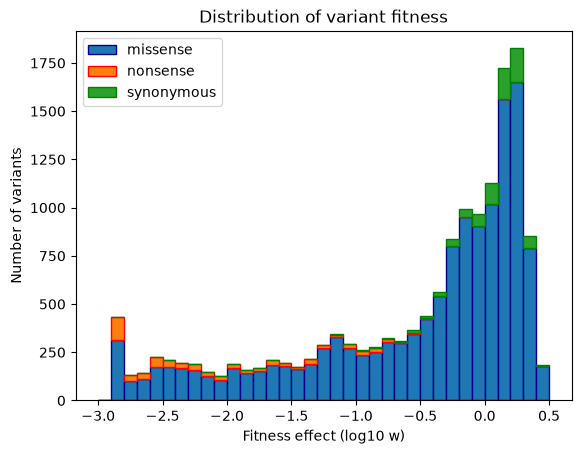

In [16]:
group_missense = protein_variants_qc[
    (protein_variants_qc["mut_aa"] != "Ter")
    & (~protein_variants_qc["is_wt_synonymous"])
]
group_nonsense = protein_variants_qc[
    protein_variants_qc["mut_aa"] == "Ter"
]
group_synonymous = protein_variants_qc[
    protein_variants_qc["is_wt_synonymous"]
]

log_w_missense = np.log10(group_missense["w"])
log_w_nonsense = np.log10(group_nonsense["w"])
log_w_synonymous = np.log10(group_synonymous["w"])

fig, ax = plt.subplots()
ax.hist(
    [log_w_missense, log_w_nonsense, log_w_synonymous],
    bins=np.arange(-3, 0.6, 0.1),
    stacked=True,
    edgecolor=("darkblue", "red", "green"),
    label=["missense", "nonsense", "synonymous"],
)
ax.set_xlabel("Fitness effect (log10 w)")
ax.set_ylabel("Number of variants")
ax.set_title("Distribution of variant fitness")
ax.legend()

fraction_above_wt = (group_missense["w"] > 1).mean() * 100
print(f"Missense variants with w above 1: {fraction_above_wt:.1f}%")

fraction_above_wt_well_measured = (
    group_missense[group_missense["c_total"] >= 200]["w"] > 1
).mean() * 100
print(
    f"Same, restricted to c_total >= 200: "
    f"{fraction_above_wt_well_measured:.1f}%"
)

The distribution matches the general shape reported in the original
publication: nonsense variants cluster near -3 (near-complete loss of
function), synonymous variants near 0 (wild-type-like), and missense
variants spread across the full range.

One notable difference: 37.9% of missense variants have `w` above 1
here, against 7.0% in the original publication. This gap shrinks to
8.1% when restricted to well-measured variants (`c_total` >= 200), which
points to low-count sampling noise as the main driver rather than the
exponential in the fitness formula itself. The original publication
avoids this by only counting a fitness gain as real when it falls outside
an estimated error margin, a step not implemented in this simplified
method.

### Score per position

A single summary score per position is computed from missense
substitutions only, excluding synonymous and nonsense variants: the
number of synonymous codons available varies by wild-type amino acid,
which would bias comparisons between positions, and nonsense variants
answer a different question (loss of function, not substitution
tolerance).

The median is used rather than the mean, as in steps 4 and 5: `w`'s
exponential formula makes it right-skewed, and the median stays more
robust to this asymmetry when summarising multiple substitutions.

In [17]:
median_score_position = group_missense.groupby("position")["w"].median()

In [18]:
published = pd.read_excel(
    "Data_S1-S4.xlsx", sheet_name="S4 k-star effective # of AA"
)
article_k_star = published[["Ambler Position", "k*"]]
article_k_star = article_k_star.rename(columns={"Ambler Position": "ambler"})
article_k_star = article_k_star.dropna(subset="ambler")
article_k_star["ambler"] = article_k_star["ambler"].astype(int)

position_to_ambler = protein_variants_qc.groupby("position")["ambler"].first()
median_score = median_score_position.to_frame("median_w")
median_score = median_score.join(position_to_ambler)
merged_kstar = article_k_star.merge(median_score, on="ambler", how="inner")

statistic, _ = spearmanr(merged_kstar["median_w"], merged_kstar["k*"])
print(f"Positions matched: {len(merged_kstar)}")
print(f"Spearman correlation with published k*: rho = {statistic:.3f}")

Positions matched: 285
Spearman correlation with published k*: rho = 0.932


C:\Users\MélineKURIC\AppData\Roaming\Python\Python314\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


The median score per position is not biologically interpreted here: it
serves as input for the heatmap below and for step 7. It is however
compared to k*, the effective number of tolerated amino acids published
in Firnberg et al.'s Data S4, a more informative but more complex summary
of positional tolerance (see limitations). The two measures are strongly
correlated (Spearman, rho = 0.932, n = 285), confirming that the median
used throughout this notebook is a reasonable proxy for k*, despite
masking the bimodality that k* can capture.

### Heatmap of median w by position and substitution

The full grid, covering all 286 positions and 20 amino acids, gives a
global overview of the fitness landscape before the position-level
analysis in step 7. Rows are ordered by the amino acid chemical groups
defined in the constants cell, keeping similar amino acids adjacent.

Text(0.5, 1.0, 'Median missense fitness by position')

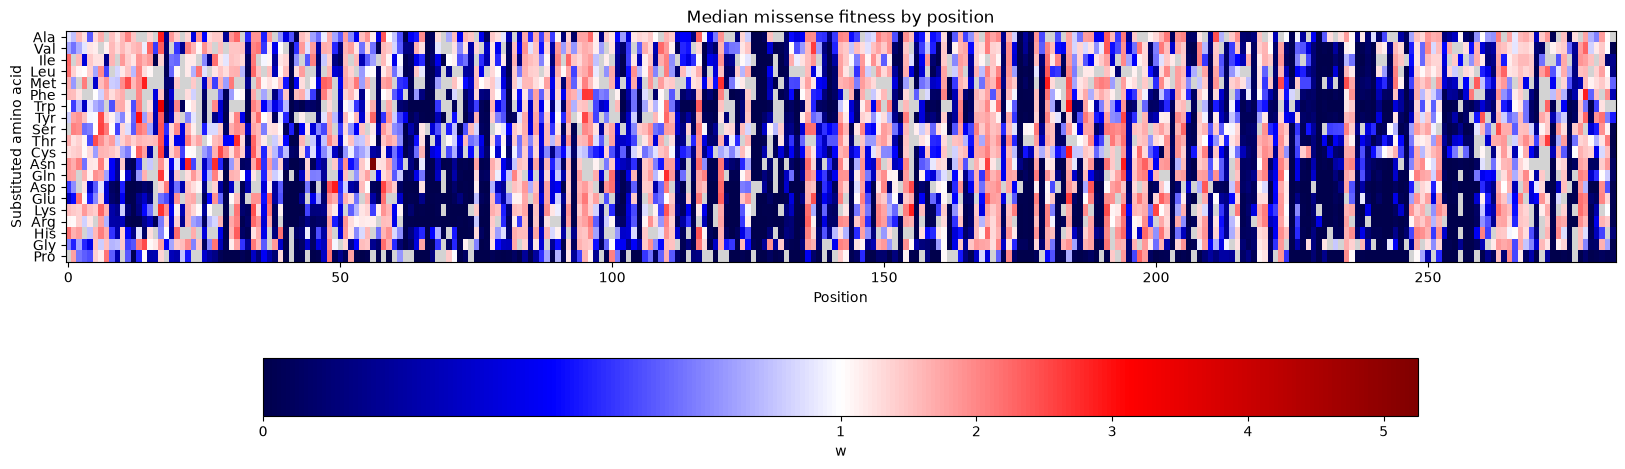

In [19]:
median_score_grid = group_missense.pivot_table(
    index="position", columns="mut_aa", values="w", aggfunc="median"
).reindex(columns=AA_ORDER)

norm = TwoSlopeNorm(
    vcenter=1,
    vmin=0,
    vmax=median_score_grid.max().max(),
)

fig, ax = plt.subplots(figsize=(20, 5))
cmap = copy.copy(plt.get_cmap("seismic"))
cmap.set_bad(color="lightgray")
im = ax.imshow(
    median_score_grid.T,
    cmap=cmap,
    norm=norm,
    aspect="auto",
)

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.25)
cbar.set_label("w")
cbar.set_ticks([0, 1, 2, 3, 4, 5])

ax.set_xlabel("Position")
ax.set_ylabel("Substituted amino acid")
ax.set_yticks(range(20), AA_ORDER)
ax.set_title("Median missense fitness by position")

### Clustering of intolerant and beneficial positions

To ask whether intolerant and beneficial positions are randomly
distributed along the sequence or cluster together, the bottom and top
30% of positions by median missense `w` (86 positions each) are
identified and compared by counting blocks of consecutive positions
against what random selections give. A 30% cutoff gives groups large
enough to detect clustering while remaining strict enough to separate
clearly intolerant from clearly beneficial positions.

In [20]:
n_selected = round(len(median_score_position) * 0.3)

sorted_scores = median_score_position.sort_values()
worst_30pct = sorted_scores.head(n_selected).index
best_30pct = sorted_scores.tail(n_selected).index

is_intolerant = median_score_position.index.isin(worst_30pct)
is_beneficial = median_score_position.index.isin(best_30pct)

np.random.seed(0)
n_permutations = 10_000
for name, mask in [("Bottom 30%", is_intolerant), ("Top 30%", is_beneficial)]:
    block_lengths = [
        len(list(group))
        for value, group in itertools.groupby(mask)
        if value
    ]
    n_blocks = len(block_lengths)

    null_blocks = []
    for _ in range(n_permutations):
        shuffled = np.random.permutation(mask)
        shuffled_lengths = [
            len(list(group))
            for value, group in itertools.groupby(shuffled)
            if value
        ]
        null_blocks.append(len(shuffled_lengths))
    n_as_few = len([n for n in null_blocks if n <= n_blocks])
    p_value = (n_as_few + 1) / (n_permutations + 1)
    print(
        f"{name} ({n_selected} positions): {n_blocks} blocks (largest: "
        f"{max(block_lengths)} positions), {np.mean(null_blocks):.1f} "
        f"expected by chance, p = {p_value:.4f}"
    )

Bottom 30% (86 positions): 43 blocks (largest: 9 positions), 60.4 expected by chance, p = 0.0001
Top 30% (86 positions): 59 blocks (largest: 3 positions), 60.4 expected by chance, p = 0.3987


The bottom 30% form 43 blocks, the largest spanning 9 consecutive
positions; the top 30% form 59 blocks, none larger than 3. Shuffling the
positions 10,000 times gives 60.4 blocks on average for a selection this
size. The intolerant positions form far fewer blocks than expected by
chance (p < 0.001): they cluster along the sequence. The beneficial
positions form as many blocks as chance gives (p = 0.40): they show no
clustering.

## Step 7: Biological interpretation

The score distribution and position-level summary from step 6 are used
to ask a concrete biological question: do the least tolerant positions
correspond to residues known to be functionally critical in TEM-1? This
check is done blind, by extracting the 15 least and most tolerant
positions directly from the data, before looking up the known
active-site residues.

The 15 least and most tolerant positions are selected as a pragmatic
choice: large enough to reveal structural and functional patterns, small
enough for individual positions to be labelled and discussed.

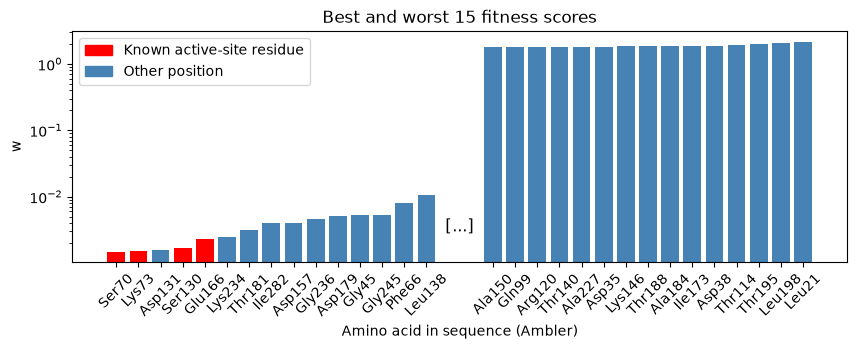

In [21]:
worst_positions = sorted_scores.head(N_POSITIONS_PER_GROUP)
best_positions = sorted_scores.tail(N_POSITIONS_PER_GROUP)

both_positions = pd.concat([worst_positions, best_positions])
w_scores = both_positions.values
position_ordered = both_positions.index

x_worst = np.arange(N_POSITIONS_PER_GROUP)
x_best = np.arange(N_POSITIONS_PER_GROUP) + N_POSITIONS_PER_GROUP + 2
x_positions = np.concatenate([x_worst, x_best])

bar_labels = [get_ambler_label(pos) for pos in position_ordered]

active_site_positions = [68, 71, 128, 164]
bar_colors = [
    "red" if pos in active_site_positions else "steelblue"
    for pos in position_ordered
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(x_positions, w_scores, color=bar_colors)
ax.set_xticks(x_positions, bar_labels, rotation=45)
ax.set_yscale("log")
ax.set_xlabel("Amino acid in sequence (Ambler)")
ax.set_ylabel("w")
ax.set_title(
    f"Best and worst {N_POSITIONS_PER_GROUP} fitness scores"
)
ax.text(N_POSITIONS_PER_GROUP + 0.5, 0.003, "[...]", ha="center", fontsize=12)

legend_handles = [
    mpatches.Patch(color="red", label="Known active-site residue"),
    mpatches.Patch(color="steelblue", label="Other position"),
]
ax.legend(handles=legend_handles)

The four established catalytic residues of class A beta-lactamases,
Ser70, Lys73, Ser130, and Glu166, are indeed among the 15 least tolerant
positions in the dataset, confirming that the fitness landscape captures
known functional constraints even without prior structural knowledge.
This blind recovery is robust: all four active-site residues rank among
the 5 least tolerant positions overall.

Text(0.5, 1.0, 'Missense fitness for the 15 least and most tolerant positions')

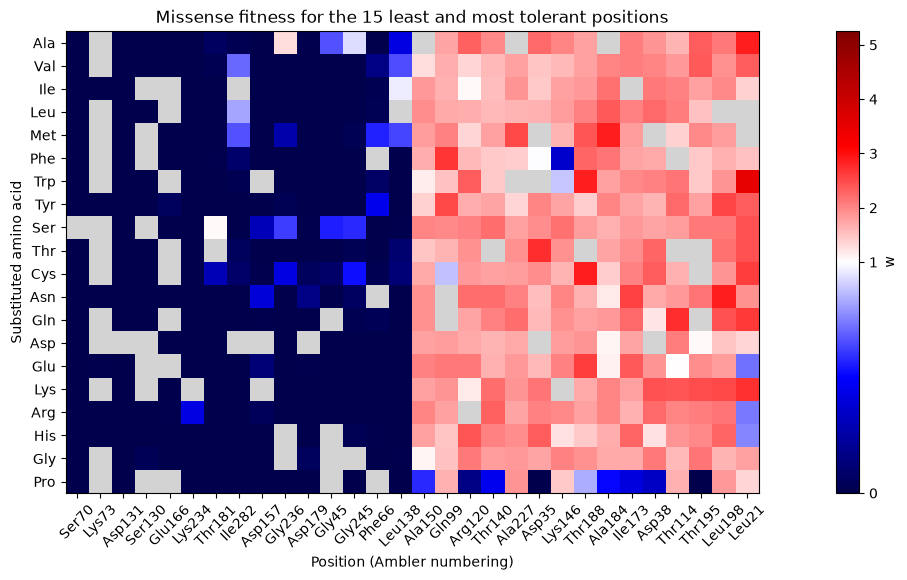

In [22]:
extreme_positions_grid = median_score_grid.loc[position_ordered]

labels_heatmap = [
    get_ambler_label(pos) for pos in extreme_positions_grid.index
]

fig, ax = plt.subplots(figsize=(20, 6))
cmap = copy.copy(plt.get_cmap("seismic"))
cmap.set_bad(color="lightgray")
im = ax.imshow(extreme_positions_grid.T, cmap=cmap, norm=norm)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("w")
cbar.set_ticks([0, 1, 2, 3, 4, 5])

ax.set_xlabel("Position (Ambler numbering)")
ax.set_ylabel("Substituted amino acid")
ax.set_xticks(range(len(labels_heatmap)), labels_heatmap, rotation=45)
ax.set_yticks(range(20), extreme_positions_grid.columns)
ax.set_title(
    f"Missense fitness for the {N_POSITIONS_PER_GROUP} least and most "
    "tolerant positions"
)

The heatmap confirms the bar chart findings. Gray cells are either the
wild-type amino acid (excluded by construction) or variants below
`QC_MIN_COUNT`; positions with many gray cells, such as Lys73, likely
reflect variants too deleterious to accumulate reads.

Among the 15 least tolerant positions, almost every cell is dark blue or
gray, with one exception: alanine at Gly236 (w = 1.29, against a median
of 0.005 across all substitutions there). Serine and cysteine also show
partial tolerance, though still far from wild-type levels.

Among the 15 most tolerant positions, almost every cell is red or light
pink. Proline is dark blue at nearly every position, consistent with the
original publication's finding that it is the least tolerated
substitution overall. Leu21 has the highest median missense `w` of all
positions yet the most heterogeneous pattern: charged amino acids (Arg,
His, Glu) are strongly deleterious while most others are beneficial. The
original publication identifies Leu21 as a hotspot for beneficial
mutations in the signal sequence, where charged residues disrupt export
while hydrophobic ones are tolerated or beneficial.

### Structural context from UniProt

Secondary structure annotations for TEM-1 (UniProt P62593) are retrieved
and mapped to the 30 extreme positions identified above, each assigned to
a helix, beta strand, turn, or loop by its annotated boundaries. The
table below summarises intolerant and beneficial positions by structure
type.

In [23]:
with urllib.request.urlopen(UNIPROT_URL) as response:
    uniprot_data = json.loads(response.read())

secondary_structures = [
    {
        "type": feature["type"],
        "start": feature["location"]["start"]["value"],
        "end": feature["location"]["end"]["value"],
    }
    for feature in uniprot_data["features"]
    if feature["type"] in ("Helix", "Beta  strand", "Turn", "Signal")
]

list_structure = []
for position in position_ordered:
    for structure in secondary_structures:
        if structure["start"] <= position <= structure["end"]:
            list_structure.append(structure["type"])
            break
    else:
        list_structure.append("Loop")

structure_df = pd.DataFrame({
    "position": position_ordered,
    "structure": list_structure,
    "w": median_score_position[position_ordered].values,
})
structure_df["ambler"] = structure_df["position"].apply(
    get_ambler_label
)
structure_df["intolerant"] = structure_df["position"].isin(
    worst_positions.index
)
structure_df["beneficial"] = structure_df["position"].isin(
    best_positions.index
)

intolerant_by_structure = (
    structure_df[structure_df["intolerant"]]
    .groupby("structure")["ambler"]
    .agg(list)
)
beneficial_by_structure = (
    structure_df[structure_df["beneficial"]]
    .groupby("structure")["ambler"]
    .agg(list)
)
structure_summary = pd.concat(
    [
        structure_df.groupby("structure")["w"].agg(
            ["count", "median", "mean"]
        ),
        intolerant_by_structure.rename("intolerant"),
        beneficial_by_structure.rename("beneficial"),
    ],
    axis=1
)
structure_summary

,count,median,mean,intolerant,beneficial
structure,,,,,
Helix,13,1.787125,1.260893,"[Ser70, Lys73, Ile282, Leu138]","[Ala150, Gln99, Arg120, Thr140, Asp35, Lys146,..."
Loop,14,0.004885,0.419703,"[Asp131, Ser130, Glu166, Lys234, Thr181, Asp15...","[Ala227, Thr195, Leu198]"
Signal,1,2.167739,2.167739,NaN,[Leu21]
Turn,2,1.870179,1.870179,NaN,"[Ile173, Thr114]"


Helices contain the largest share of beneficial positions (9 of 15), but
also four intolerant ones, including two of the four catalytic residues
(Ser70, Lys73): being in a helix does not by itself predict whether a position tolerates substitution, its functional role does. Whether the predominance of beneficial positions in helices reflects surface exposure or other properties cannot be determined from sequence data alone.

Loops carry the most intolerant positions (7 of 15), including two of
the four catalytic residues (Ser130, Glu166); the other two (Ser70,
Lys73) fall in helices, as noted above. The two turns in this set are
both beneficial, with the highest median `w` of any category (1.87).
Beta strands show a bimodal distribution: four intolerant positions alongside 
two beneficial ones, a low median (0.005) but a mean pulled to 0.67 by the beneficial outliers, consistent with strand residues typically pointing 
alternately inward and outward, though this would need structural confirmation.
Leu21, the most tolerant position overall, falls in the signal peptide
(UniProt positions 1-23), absent from the crystal structures and reported
here as its own category.

### Fitness by substituted amino acid

The same data can also be summarised by substituted amino acid: for each
of the 20 amino acids, the median missense `w` across all positions is
plotted, showing which substitutions are globally tolerated or
deleterious regardless of position.

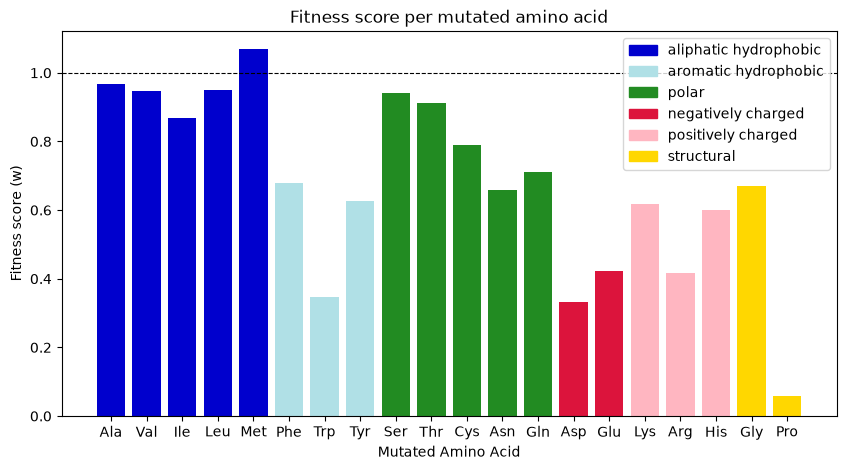

In [24]:
mutated_aa = median_score_grid.median().reindex(AA_ORDER)

aa_bar_colors = [AA_COLORS[AA_GROUPS[aa]] for aa in mutated_aa.index]
legend_handles = [
    mpatches.Patch(color=color, label=group)
    for group, color in AA_COLORS.items()
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(mutated_aa.index.astype(str), mutated_aa, color=aa_bar_colors)
ax.axhline(y=1, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Mutated Amino Acid")
ax.set_ylabel("Fitness score (w)")
ax.set_title("Fitness score per mutated amino acid")
ax.legend(handles=legend_handles)

Substituting most amino acids into TEM-1 is on average deleterious: all
groups have a median `w` below 1 except methionine. Aliphatic hydrophobic substitutions are the best tolerated overall in this dataset, while proline 
is by far the least tolerated, matching the original publication's own finding. Among aromatics, tryptophan is more deleterious than phenylalanine and 
tyrosine, likely reflecting its larger side chain.

## Step 8: Codon-level analysis

Multiple codons can encode the same amino acid, so variants at the same
position with the same substituted amino acid may differ only in their
nucleotide sequence. This step asks whether codon choice affects fitness,
and whether this depends on a position's tolerance to substitution or its
location at the start of the gene.

Two columns are added to `protein_variants_qc`: `mutated_codon`
(reconstructed from the HGVS nucleotide notation) and `codon_freq` (the
mutated codon's frequency in highly expressed *E. coli* genes, Lorimer et
al., 2009, Table 3). For each position/substituted-amino-acid pair with
at least two variants, including the synonymous pair at each position,
the variant with the highest and lowest `w` are identified. The fitness
spread is log2 of their ratio, since a plain difference in `w` would be
near zero at intolerant positions regardless of codon. The codon
frequency spread is the plain difference in frequency. This is done on
three groups of 15 positions: the least tolerant, the most tolerant, and
positions 2 to 16.

Positions 2 to 16 replace the original publication's 2 to 10: their
9-position window is too small for reliable Kruskal-Wallis inference,
and 15 matches the other two groups. Position 1, the start codon, is
excluded throughout (see step 2). The question stays the same: is a codon
effect detectable where the original publication reports strong
synonymous fitness effects?

In [25]:
protein_variants_qc["mutated_codon"] = [
    get_mutated_codon(hgvs_nt, position)
    for hgvs_nt, position in zip(
        protein_variants_qc["hgvs_nt"], protein_variants_qc["position"]
    )
]
protein_variants_qc["codon_freq"] = protein_variants_qc["mutated_codon"].map(
    lambda codon: ECOLI_CODON_TABLE[codon.replace("T", "U")][1]
)

Fitness spread analysis
Intolerant: 194 pairs, median spread 0.49 (Shapiro-Wilk p = 6.9e-16), median of 2 variants per pair, 46% with 3+ variants
Positions 2-16: 230 pairs, median spread 0.74 (Shapiro-Wilk p = 1.6e-15), median of 3 variants per pair, 51% with 3+ variants
Beneficial: 232 pairs, median spread 0.47 (Shapiro-Wilk p = 7.6e-19), median of 3 variants per pair, 53% with 3+ variants
Kruskal-Wallis: H = 17.0, p = 2.0e-04
Dunn post-hoc p-values (Bonferroni):
Intolerant vs Positions 2-16: p = 0.012
Intolerant vs Beneficial: p = 1
Positions 2-16 vs Beneficial: p = 0.00021

Codon frequency spread analysis
Intolerant: median = +0.000 (Shapiro-Wilk p = 2.0e-07, Wilcoxon p = 0.901)
Positions 2-16: median = +0.020 (Shapiro-Wilk p = 4.3e-10, Wilcoxon p = 0.066)
Beneficial: median = -0.020 (Shapiro-Wilk p = 9.5e-10, Wilcoxon p = 0.251)


Text(0.5, 1.0, 'Codon frequency difference by position tolerance')

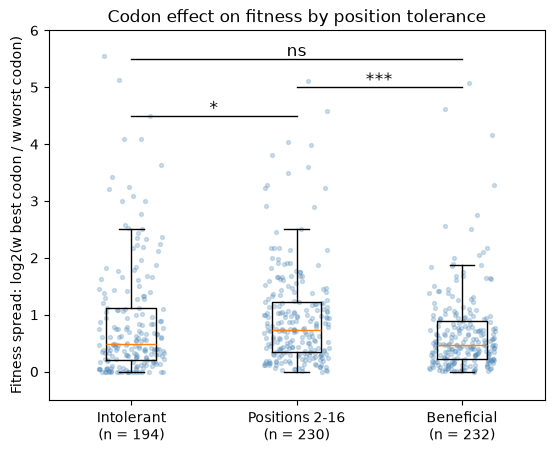

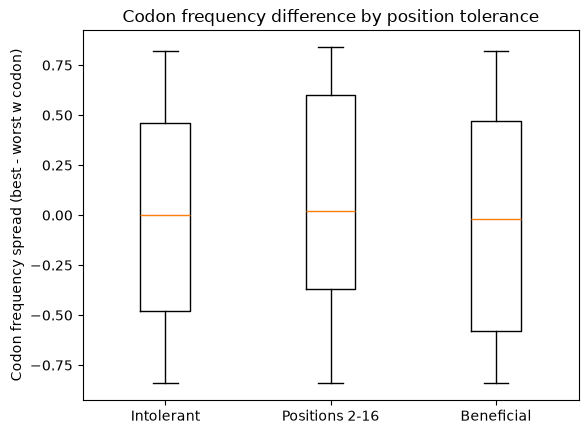

In [26]:
not_nonsense = protein_variants_qc["mut_aa"] != "Ter"
best_of_aa = protein_variants_qc[
    protein_variants_qc["position"].isin(best_positions.index) & not_nonsense
]
worst_of_aa = protein_variants_qc[
    protein_variants_qc["position"].isin(worst_positions.index) & not_nonsense
]
early_aa = protein_variants_qc[
    protein_variants_qc["position"].between(2, N_POSITIONS_PER_GROUP + 1)
    & not_nonsense
]

worst_spread, worst_freq_spread = compute_spreads(worst_of_aa, "codon_freq")
early_spread, early_freq_spread = compute_spreads(early_aa, "codon_freq")
best_spread, best_freq_spread = compute_spreads(best_of_aa, "codon_freq")

group_labels = [
    "Intolerant",
    f"Positions 2-{N_POSITIONS_PER_GROUP + 1}",
    "Beneficial",
]
w_groups = [worst_spread, early_spread, best_spread]
freq_groups = [worst_freq_spread, early_freq_spread, best_freq_spread]
subsets = [worst_of_aa, early_aa, best_of_aa]

print("Fitness spread analysis")
min_variants = 2
for label, spread, subset in zip(group_labels, w_groups, subsets):
    _, shapiro_p = shapiro(spread)
    sizes = subset.groupby(["position", "mut_aa"]).size()
    sizes = sizes[sizes >= min_variants]
    share_large = (sizes >= 3).sum() / len(sizes) * 100
    print(
        f"{label}: {len(spread)} pairs, median spread {np.median(spread):.2f} "
        f"(Shapiro-Wilk p = {shapiro_p:.1e}), median of {sizes.median():.0f} "
        f"variants per pair, {share_large:.0f}% with 3+ variants"
    )

h_statistic, h_pvalue = kruskal(*w_groups)
print(f"Kruskal-Wallis: H = {h_statistic:.1f}, p = {h_pvalue:.1e}")

dunn_pvalues = sp.posthoc_dunn(w_groups, p_adjust="bonferroni")

print("Dunn post-hoc p-values (Bonferroni):")
for i in range(len(group_labels)):
    for j in range(i + 1, len(group_labels)):
        p_value = dunn_pvalues.iloc[i, j]
        print(f"{group_labels[i]} vs {group_labels[j]}: p = {p_value:.2g}")

# In the Dunn table, 0 = Intolerant, 1 = Positions 2-16, 2 = Beneficial.
stars_intol_early = p_to_stars(dunn_pvalues.iloc[0, 1])
stars_intol_benef = p_to_stars(dunn_pvalues.iloc[0, 2])
stars_early_benef = p_to_stars(dunn_pvalues.iloc[1, 2])

tick_labels = [
    f"{label}\n(n = {len(spread)})"
    for label, spread in zip(group_labels, w_groups)
]

np.random.seed(0)
fig, ax = plt.subplots()
ax.boxplot(w_groups, tick_labels=tick_labels, showfliers=False)
for x, spread in enumerate(w_groups, start=1):
    jitter = np.random.uniform(-0.2, 0.2, len(spread))
    ax.scatter(x + jitter, spread, s=8, alpha=0.25, color="steelblue")
ax.set_ylabel("Fitness spread: log2(w best codon / w worst codon)")
ax.set_title("Codon effect on fitness by position tolerance")
ax.set_ylim(-0.5, 6)
ax.plot([1, 2], [4.5, 4.5], color="black", linewidth=1)
ax.text(1.5, 4.55, stars_intol_early, ha="center", fontsize=12)
ax.plot([1, 3], [5.5, 5.5], color="black", linewidth=1)
ax.text(2.0, 5.55, stars_intol_benef, ha="center", fontsize=12)
ax.plot([2, 3], [5, 5], color="black", linewidth=1)
ax.text(2.5, 5.05, stars_early_benef, ha="center", fontsize=12)

print("\nCodon frequency spread analysis")
for label, spread in zip(group_labels, freq_groups):
    _, shapiro_p = shapiro(spread)
    _, wilcoxon_p = wilcoxon(spread)
    print(
        f"{label}: median = {np.median(spread):+.3f} "
        f"(Shapiro-Wilk p = {shapiro_p:.1e}, Wilcoxon p = {wilcoxon_p:.3f})"
    )

fig, ax = plt.subplots()
ax.boxplot(freq_groups, tick_labels=group_labels)
ax.set_ylabel("Codon frequency spread (best - worst w codon)")
ax.set_title("Codon frequency difference by position tolerance")

The fitness spread differs between groups (Kruskal-Wallis, p < 0.001).
Dunn tests (Bonferroni) show positions 2 to 16 have a larger spread
(median log2 ratio 0.74, about 1.7-fold) than both the beneficial (0.47,
p < 0.001) and intolerant positions (0.49, p = 0.012), while intolerant
and beneficial do not differ (p = 1). In relative terms, codon choice
therefore matters more at the start of the gene, consistent with the
original publication, independent of substitution tolerance; the
mechanism itself is not tested here.

Pair sizes are similar for positions 2-16 and beneficial positions
(median 3 variants/pair, 51% and 53% with 3+), so their difference is not
explained by pair size. Intolerant pairs are slightly smaller (median 2,
46% with 3+), making that comparison the less certain of the two.

The codon frequency spread, by contrast, favours neither codon clearly. A
Wilcoxon test against zero is not significant for intolerant (p = 0.90)
or beneficial positions (p = 0.25). Positions 2 to 16 come closer
(p = 0.066, median +0.02): the best codon is slightly more often the more
frequent one here than elsewhere, a trend consistent with, though weaker
than, the original publication's finding that favoured codons at the
start of the gene tend to be more frequent in the genome. Overall, codon
frequency in this table remains a weak predictor of fitness.

### Step 9: mRNA structure at the start of the gene

The original publication attributes part of the fitness effect of
synonymous substitutions near the start of the gene to changes in mRNA
structure around the translation start site, comparing pairs of
synonymous codons with RNAfold. The same principle is applied here,
generalised to every pair of codons for the same amino acid at the same
position (not only synonymous pairs), reusing the pair construction from
step 8.

For each variant at positions 2 to 16, the wild-type codon is replaced by
the variant's codon, and the minimum free energy (MFE) of the first 50
nucleotides of the gene is computed with ViennaRNA before and after the
substitution. `delta_mfe` is the difference: positive means the mutation
makes this region less stable. This fixed window, anchored at the start
of the gene rather than centred on each mutation, captures the region
around the ribosome binding site regardless of where the mutation falls
within positions 2 to 16; it excludes the plasmid's 5' untranslated
region, not part of this dataset.

For each pair, the best and worst codon from step 8 are reused, and the
difference in `delta_mfe` between them is computed the same way as the
fitness and codon frequency spreads in step 8. If mRNA structure explains
part of the best codon's advantage, this difference is expected to be
positive on average: the best codon should leave the region less stable
than the worst.

In [27]:
is_early = (
    protein_variants_qc["position"].between(2, N_POSITIONS_PER_GROUP + 1)
)
early_variants = protein_variants_qc[is_early & not_nonsense].copy()

cut_tem = TEM1_SEQUENCE[:WINDOW]
_, tem_mfe = RNA.fold(cut_tem)

for idx, row in early_variants.iterrows():
    nuc_pos = (int(row["position"]) - 1)*3
    muted_list = list(TEM1_SEQUENCE)
    muted_list[nuc_pos: nuc_pos+3] = list(row["mutated_codon"])
    muted_seq = "".join(muted_list)
    cut_muted_seq = muted_seq[:WINDOW]

    if cut_tem != cut_muted_seq:
        _, muted_mfe = RNA.fold(cut_muted_seq)
        early_variants.at[idx, "delta_mfe"] = muted_mfe - tem_mfe

_, mfe_spread = compute_spreads(early_variants, "delta_mfe")

n_pairs = len(mfe_spread)
n_zero = int((mfe_spread == 0).sum())
nonzero_spread = mfe_spread[mfe_spread != 0]
print(f"Pairs with a codon-level MFE comparison: {n_pairs}")
print(f"Pairs with no MFE difference between codons: {n_zero}")

statistic, pvalue = shapiro(mfe_spread)
print(f"Shapiro-Wilk: W = {statistic:.3f}, p = {pvalue:.1e}")

statistic, pvalue = wilcoxon(mfe_spread)
print(
    f"Wilcoxon signed-rank test vs 0: statistic = {statistic:.1f}, "
    f"p = {pvalue:.3f}"
)
print(f"Median MFE spread (all pairs): {np.median(mfe_spread):.2f} kcal/mol")
print(
    f"Median MFE spread (pairs with a difference): "
    f"{np.median(nonzero_spread):.2f} kcal/mol"
)
n_positive = int((nonzero_spread > 0).sum())
n_negative = int((nonzero_spread < 0).sum())
print(
    f"Direction: {n_positive} pairs with a less stable best codon, "
    f"{n_negative} pairs with a more stable best codon"
)

Pairs with a codon-level MFE comparison: 230
Pairs with no MFE difference between codons: 106
Shapiro-Wilk: W = 0.777, p = 2.1e-17
Wilcoxon signed-rank test vs 0: statistic = 2631.0, p = 0.002
Median MFE spread (all pairs): 0.00 kcal/mol
Median MFE spread (pairs with a difference): 0.25 kcal/mol
Direction: 73 pairs with a less stable best codon, 51 pairs with a more stable best codon


Among the 230 pairs, 106 show no MFE difference between the best and
worst codon: the substitution falls inside the window but does not
change the predicted structure. Restricted to the 124 pairs with a
genuine difference, the spread is not normally distributed
(Shapiro-Wilk, p < 0.001), so a Wilcoxon test compares it to zero: it
differs significantly (p = 0.002), with 73 pairs where the best codon
leaves the region less stable against 51 with the opposite pattern. The
median spread among these 124 pairs is 0.25 kcal/mol, modest relative to
the wild-type window's own MFE (around -7.2 kcal/mol).

This points in the same direction as the original publication: the codon
with the best fitness tends to destabilise the mRNA structure at the
start of the gene slightly more often than not. The effect is weaker and
noisier than theirs, likely because this analysis pools all amino acids
at positions 2 to 16 rather than synonymous pairs alone, and because the
window used here starts at the first codon rather than extending into
the plasmid's 5' untranslated region.

## Conclusion

This notebook reproduces and extends the fitness landscape of TEM-1
beta-lactamase from Firnberg et al. (2014). The main findings agree with
the original publication: the four catalytic residues (Ser70, Lys73,
Ser130, Glu166) are the least tolerant positions; proline is the least
tolerated substitution overall; and Leu21 is a hotspot for beneficial
mutations in the signal sequence. Intolerant positions concentrate
primarily in loops while beneficial positions predominate in helices,
though two catalytic residues fall in helices, showing that structure
type alone does not determine functional constraint. Intolerant positions
also cluster along the sequence far more than expected by chance, while
beneficial positions are scattered as chance would predict. Both the
fitness scores and the per-position tolerance computed here correlate
strongly with the original publication's own published values (Spearman
rho = 0.965 and 0.932), confirming that the simplified fitness equation
used here does not distort the resulting landscape.

The codon-level analysis extends these results: the best and worst codon
for the same substitution differ in fitness by a median of about
1.4-fold at intolerant and beneficial positions alike, and about 1.7-fold
at the start of the gene, consistent with the original publication's
report of strong synonymous fitness effects there (these values include
measurement noise). Codon frequency in a reference table of highly
expressed *E. coli* genes is not a reliable predictor of the best codon,
suggesting the effect is not driven by simple tRNA adaptation.
Consistent with the mechanism the original publication proposes, the
best codon at the start of the gene tends to leave the predicted mRNA
structure slightly less stable than the worst, though the effect is
modest and absent for about half of all pairs.

This landscape characterises single substitutions in isolation.
Epistatic interactions, which shape the evolutionary trajectories
available to TEM-1, remain outside its scope and could be addressed
experimentally through combinatorial libraries or computationally
through protein language models and machine learning trained on deep
mutational scanning data. Whether the positions found tolerant here also
correspond to those that vary among natural TEM alleles is left open:
UniProt lists only ten natural substitutions for this protein, too few
for a reliable test on their own.

## Limitations

**Fitness equation and noise controls.** `f` is the weighted average of
log2 ampicillin concentrations across all 13 plates, not the original
publication's 4-plate sliding window, which reduces plate-to-plate noise.
Nor does this notebook apply their per-variant error margin: every `w`
above 1 is taken at face value, inflating the raw count of apparent gains
in step 6 (37.9% of missense variants above 1, 8.1% among well-measured
ones). Variants spread over many plates, which the original publication
attributes to sequencing errors or an unintended mutation, are likewise
not filtered out (step 5). Individual variant scores throughout this
notebook therefore carry more residual noise than in the original
publication, though this mostly affects single measurements rather than
the overall landscape (see the median/k* comparison below).

**Median as position summary.** A single median `w` per position masks
the underlying bimodality at heterogeneous positions such as Gly236 or
Leu21. The median correlates strongly with the published k*
(Spearman, rho = 0.932, step 6), suggesting limited practical impact
here, but k* was not itself recomputed and remains a more informative
summary in principle.

**Structural analysis.** Secondary structure comes from UniProt (derived
from PDB structure 1XPB); solvent-accessible surface area, which the
original publication finds correlates with tolerance, and distance to
the active site are outside the scope of this notebook.

**Codon-level analysis.** Step 8 covers only 45 of 286 positions (15
least tolerant, 15 most tolerant, positions 2-16), so conclusions on
codon effects do not generalise to the full sequence without extending
the analysis. The *E. coli* codon usage table used there is derived from
15 highly expressed genes (Lorimer et al., 2009), not the complete genome
or the SNO301 strain used in the original experiment. Pair sizes are
similar for positions 2-16 and beneficial positions (median 3
variants/pair), making the intolerant group, with smaller pairs (median
2), the least certain of the three comparisons. Several amino acids at
the same position are also treated as independent pairs despite sharing
that position.

**mRNA structure window.** Step 9 uses a single 50-nucleotide window
anchored at the start codon, excluding the plasmid's 5' untranslated
region and ribosome binding site, which the original publication's own
windows do include. The result also pools all amino acids rather than
restricting to synonymous pairs as in the original publication.

## References

Firnberg E, Labonte JW, Gray JJ, Ostermeier M. A comprehensive,
high-resolution map of a gene's fitness landscape. Mol Biol Evol.
2014;31(6):1581-1592. doi:10.1093/molbev/msu081

Lorimer D, Raymond A, Walchli J, Mixon M, Barrow A, Wallace E,
Grice R, Burgin A, Stewart L. Gene Composer: database software for
protein construct design, codon engineering, and gene synthesis.
BMC Biotechnology. 2009;9:36. doi:10.1186/1472-6750-9-36

Lorenz R, Bernhart SH, Honer Zu Siederdissen C, Tafer H, Flamm C,
Stadler PF, Hofacker IL. ViennaRNA Package 2.0. Algorithms Mol Biol.
2011;6:26. doi:10.1186/1748-7188-6-26

UniProt Consortium. TEM-1 beta-lactamase (P62593).
https://www.uniprot.org/uniprot/P62593

MaveDB. urn:mavedb:00000070-a-3.
https://www.mavedb.org/score-sets/urn:mavedb:00000070-a-3/